# EDA: Industry and Household Tables

This notebook explores two cleaned tables: `lightcast_industry_clean.csv` and `household_clean.csv`.

The analysis supports the group research questions:

1. How do hiring patterns differ for men vs. women across industries?
2. Do gender-based employment disparities vary between red and blue states?

At this stage, the industry table is used to understand hiring demand by industry, while the household table is used to examine the state-level distribution of household records.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

industry = pd.read_csv("../data/processed/lightcast_industry_clean.csv")
household = pd.read_csv("../data/processed/household_clean.csv")

print("Industry shape:", industry.shape)
print("Household shape:", household.shape)

display(industry.head())
display(household.head())

Industry shape: (72477, 3)
Household shape: (1348323, 4)


,ID,NAICS_2022_6,NAICS_2022_6_NAME
0,1f57d95acf4dc67ed2819eb12f049f6a5c11782c,441330.0,Automotive Parts and Accessories Retailers
1,0cb072af26757b6c4ea9464472a50a443af681ac,561320.0,Temporary Help Services
2,85318b12b3331fa490d32ad014379df01855c557,524291.0,Claims Adjusting
3,1b5c3941e54a1889ef4f8ae55b401a550708a310,522110.0,Commercial Banking
4,cb5ca25f02bdf25c13edfede7931508bfd9e858f,999999.0,Unclassified Industry


,SERIAL,STATEFIP,STATE_NAME,HHWT
0,3800,1,Alabama,11.0
1,3801,1,Alabama,61.0
2,3802,1,Alabama,67.0
3,3803,1,Alabama,199.0
4,3804,1,Alabama,68.0


## Plot 1: Top Industries by Job Postings

This plot shows the top 10 industries with the largest number of job postings in the Lightcast data. Since each row represents an industry classification linked to a job posting ID, counting records by `NAICS_2022_6_NAME` gives us a measure of hiring demand across industries.

This plot helps answer the first research question by identifying which industries have the strongest hiring demand before comparing gender representation across industries.

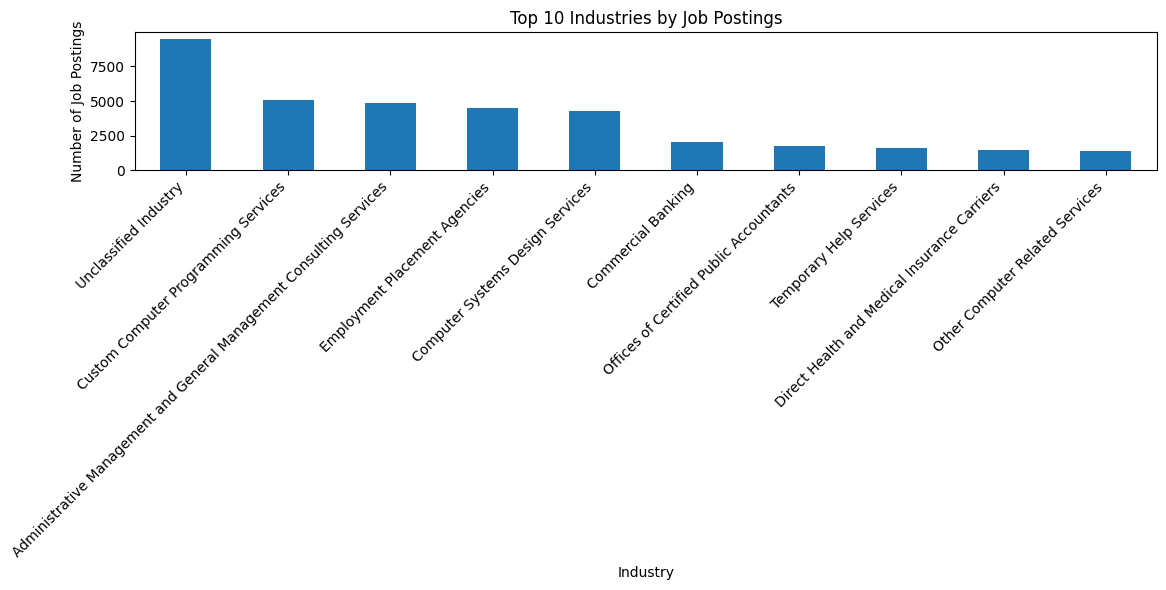

In [2]:
top_industries = industry["NAICS_2022_6_NAME"].value_counts().head(10)

plt.figure(figsize=(12, 6))
top_industries.plot(kind="bar")
plt.title("Top 10 Industries by Job Postings")
plt.xlabel("Industry")
plt.ylabel("Number of Job Postings")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Plot 2: Top States by Household Count

This plot shows the top 10 states with the largest number of household records in the household table. The variable `STATE_NAME` identifies the state for each household record.

This plot provides a state-level baseline for the second research question, which asks whether gender-based employment disparities vary between red and blue states. Before comparing employment disparities by political state category, it is useful to understand which states contribute the largest number of household observations.

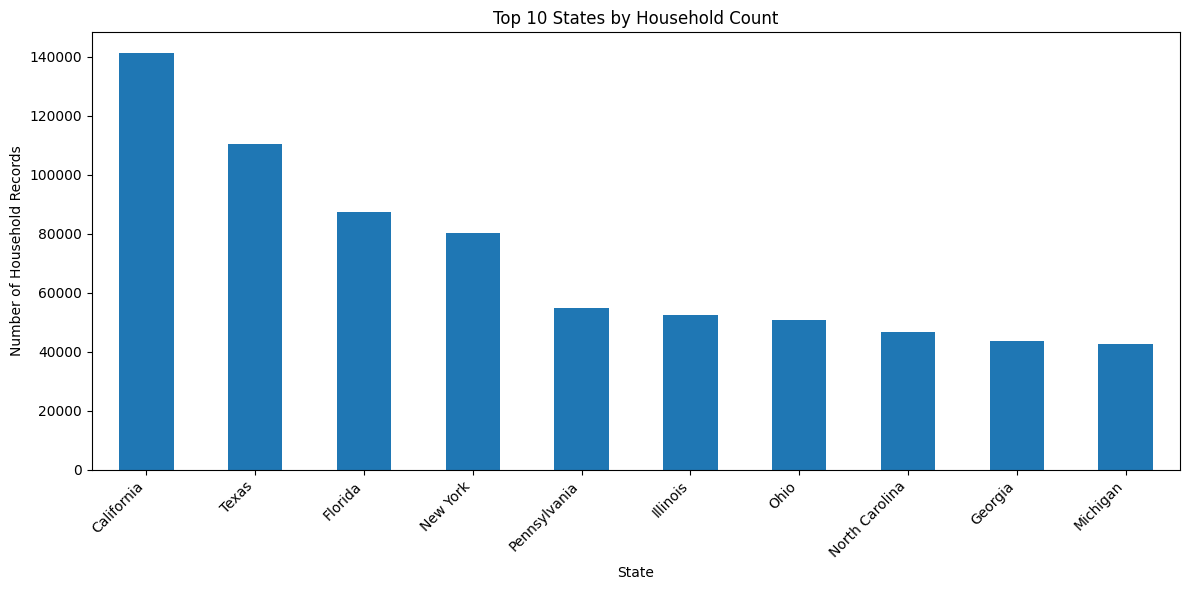

In [3]:
top_states = household["STATE_NAME"].value_counts().head(10)

plt.figure(figsize=(12, 6))
top_states.plot(kind="bar")
plt.title("Top 10 States by Household Count")
plt.xlabel("State")
plt.ylabel("Number of Household Records")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Correlation Check

The household table contains two numeric variables: `STATEFIP` and `HHWT`. We compute their correlation as a basic numeric check. However, `STATEFIP` is a categorical state identifier rather than a true continuous variable, so this correlation should not be interpreted as a meaningful causal or economic relationship.

In [4]:
household[["STATEFIP", "HHWT"]].corr()

,STATEFIP,HHWT
STATEFIP,1.000000,0.000953
HHWT,0.000953,1.000000
